In [1]:
# Установка библиотек
!pip install category-encoders==2.6.3
!pip install scikit-learn==1.3.0
!pip install optuna

In [2]:
import sys
!{sys.executable} -m pip install shap

In [3]:
import warnings 

import matplotlib.pyplot as plt 
import numpy as np 
import optuna 
import pandas as pd 
import seaborn as sns 

import shap 

import sklearn
from sklearn.dummy import DummyClassifier 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.inspection import permutation_importance 
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import ( 
    ConfusionMatrixDisplay, accuracy_score, confusion_matrix, f1_score, 
    precision_score, recall_score, roc_auc_score 
) 
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, cross_validate, train_test_split
from sklearn.pipeline import Pipeline 
from sklearn.preprocessing import StandardScaler 
from sklearn.svm import SVC 

warnings.filterwarnings("ignore")

In [5]:
# Фиксация random_state для воспроизводимости
RANDOM_STATE = 42

In [6]:
# Выгрузка данных в переменную df
df = pd.read_excel('output.xlsx')

In [7]:
df.head()

,Unnamed: 0,ai_human,word_count,avg_word_length,avg_sentence_length,MSTTR,yule,function_words,VERB,PRON,...,ADJ,NOUN,PUNCT,PROPN,DET,SCONJ,ADV,CCONJ,AUX,gunning_fog
0,0,0,435,6.921659,17.360000,0.947937,39.106883,0.218391,0.103578,0.032015,...,0.118644,0.299435,0.180791,0.016949,0.052731,0.009416,0.037665,0.032015,0.000000,30.238664
1,1,1,308,7.210526,13.818182,0.888571,50.809580,0.194805,0.132791,0.027100,...,0.113821,0.303523,0.165312,0.037940,0.021680,0.024390,0.046070,0.032520,0.005420,28.948325
2,2,0,283,6.448029,15.500000,0.886667,61.931102,0.240283,0.081152,0.034031,...,0.104712,0.311518,0.259162,0.036649,0.010471,0.005236,0.015707,0.041885,0.000000,26.200000
3,3,1,361,6.463687,16.272727,0.905000,63.688891,0.288089,0.153110,0.066986,...,0.074163,0.248804,0.136364,0.033493,0.043062,0.014354,0.050239,0.045455,0.004785,25.739860
4,5,1,330,7.272727,19.411765,0.874286,87.603306,0.215152,0.115090,0.012788,...,0.117647,0.350384,0.156010,0.005115,0.017903,0.020460,0.048593,0.038363,0.000000,32.734403


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3685 entries, 0 to 3684
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           3685 non-null   int64  
 1   ai_human             3685 non-null   int64  
 2   word_count           3685 non-null   int64  
 3   avg_word_length      3685 non-null   float64
 4   avg_sentence_length  3685 non-null   float64
 5   MSTTR                3685 non-null   float64
 6   yule                 3685 non-null   float64
 7   function_words       3685 non-null   float64
 8   VERB                 3685 non-null   float64
 9   PRON                 3685 non-null   float64
 10  NUM                  3685 non-null   float64
 11  ADJ                  3685 non-null   float64
 12  NOUN                 3685 non-null   float64
 13  PUNCT                3685 non-null   float64
 14  PROPN                3685 non-null   float64
 15  DET                  3685 non-null   f

In [9]:
columns_to_drop = ['Unnamed: 0']
df = df.drop(columns=columns_to_drop)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3685 entries, 0 to 3684
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ai_human             3685 non-null   int64  
 1   word_count           3685 non-null   int64  
 2   avg_word_length      3685 non-null   float64
 3   avg_sentence_length  3685 non-null   float64
 4   MSTTR                3685 non-null   float64
 5   yule                 3685 non-null   float64
 6   function_words       3685 non-null   float64
 7   VERB                 3685 non-null   float64
 8   PRON                 3685 non-null   float64
 9   NUM                  3685 non-null   float64
 10  ADJ                  3685 non-null   float64
 11  NOUN                 3685 non-null   float64
 12  PUNCT                3685 non-null   float64
 13  PROPN                3685 non-null   float64
 14  DET                  3685 non-null   float64
 15  SCONJ                3685 non-null   f

In [11]:
feature_cols = ['word_count', 'avg_word_length', 'avg_sentence_length', 'MSTTR',
                'yule', 'function_words', 'VERB', 'PRON', 
                'NUM', 'ADJ', 'NOUN', 'PUNCT', 'PROPN', 'DET', 'SCONJ', 'ADV', 'CCONJ', 'AUX', 
                'gunning_fog']
X = df[feature_cols]
y = df['ai_human']

In [12]:
# Разделение на тестовую и обучающую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

In [13]:
# Разделение на обучающую и валидационную выборки
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=RANDOM_STATE, stratify=y_train)

In [14]:
# Проверка распределения целевой переменной
print(f"Распределение целевой переменной в тестовой выборке")
print(f"{y_test.value_counts(normalize=True).sort_values(ascending=False)}")
print(f"\nРаспределение целевой переменной в обучающей выборке")
print(f"{y_train.value_counts(normalize=True).sort_values(ascending=False)}")
print(f"\nРаспределение целевой переменной в валидационной выборке")
print(f"{y_val.value_counts(normalize=True).sort_values(ascending=False)}")

Распределение целевой переменной в тестовой выборке
1    0.518318
0    0.481682
Name: ai_human, dtype: float64

Распределение целевой переменной в обучающей выборке
1    0.517865
0    0.482135
Name: ai_human, dtype: float64

Распределение целевой переменной в валидационной выборке
1    0.518318
0    0.481682
Name: ai_human, dtype: float64


In [15]:
print(f"Обучающая выборка: {len(X_train)}")
print(f"Валидационная выборка: {len(X_val)}")
print(f"Тестовая выборка: {len(X_test)}")

Обучающая выборка: 2211
Валидационная выборка: 737
Тестовая выборка: 737


In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'precision': 'precision',
    'recall': 'recall'
}

pipeline_dummy = Pipeline([
    ('scaler', StandardScaler()),
    ('model', DummyClassifier(strategy='prior', random_state=RANDOM_STATE))
])

dummy_results = cross_validate(
    pipeline_dummy,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [17]:
dummy_metrics = {}

for metric in scoring.keys():
    dummy_metrics[metric] = {
        'mean': np.mean(dummy_results[f'test_{metric}']),
        'std': np.std(dummy_results[f'test_{metric}'])
    }

for metric, values in dummy_metrics.items():
    print(f"{metric}: {values['mean']:.3f}")

accuracy: 0.518
f1: 0.682
roc_auc: 0.500
precision: 0.518
recall: 1.000


In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'precision': 'precision',
    'recall': 'recall'
}

pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

lr_results = cross_validate(
    pipeline_lr,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [19]:
lr_metrics = {}

for metric in scoring.keys():
    lr_metrics[metric] = {
        'mean': np.mean(lr_results[f'test_{metric}']),
        'std': np.std(lr_results[f'test_{metric}'])
    }

for metric, values in lr_metrics.items():
    print(f"{metric}: {values['mean']:.3f}")

accuracy: 0.922
f1: 0.925
roc_auc: 0.978
precision: 0.927
recall: 0.922


In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'precision': 'precision',
    'recall': 'recall'
}

pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(
        kernel='linear',                   
        random_state=RANDOM_STATE,                 
        probability=True,               
    ))
])

svm_results = cross_validate(
    pipeline_svm,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [21]:
svm_metrics = {}

for metric in scoring.keys():
    svm_metrics[metric] = {
        'mean': np.mean(svm_results[f'test_{metric}']),
        'std': np.std(svm_results[f'test_{metric}'])
    }

for metric, values in svm_metrics.items():
    print(f"{metric}: {values['mean']:.3f}")

accuracy: 0.921
f1: 0.923
roc_auc: 0.978
precision: 0.927
recall: 0.920


In [22]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'precision': 'precision',
    'recall': 'recall'
}

pipeline_svm_rbf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(
        kernel='rbf',                   
        random_state=RANDOM_STATE,                 
        probability=True,               
    ))
])

svm_rbf_results = cross_validate(
    pipeline_svm_rbf,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [23]:
svm_rbf_metrics = {}

for metric in scoring.keys():
    svm_rbf_metrics[metric] = {
        'mean': np.mean(svm_rbf_results[f'test_{metric}']),
        'std': np.std(svm_rbf_results[f'test_{metric}'])
    }

for metric, values in svm_rbf_metrics.items():
    print(f"{metric}: {values['mean']:.3f}")

accuracy: 0.941
f1: 0.943
roc_auc: 0.987
precision: 0.951
recall: 0.934


In [24]:
# параметры для LogisticRegression
logreg_param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear'],
    'classifier__class_weight': ['balanced', None]
}

# параметры для SVC
svc_param_grid = [
    {
        'classifier__kernel': ['linear'],
        'classifier__C': [0.01, 0.1, 1, 10, 100],
        'classifier__class_weight': [None, 'balanced']
    },
    {
        'classifier__kernel': ['rbf'],
        'classifier__C': [0.01, 0.1, 1, 10, 100],
        'classifier__gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
        'classifier__class_weight': [None, 'balanced']
    }
]

In [25]:
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE) 

grid_lr = GridSearchCV(
    estimator=pipeline_lr,
    param_grid=logreg_param_grid,
    cv=cv,
    scoring='roc_auc',  
    n_jobs=-1,
    verbose=1
)

In [26]:
grid_lr.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('classifier',
                                        LogisticRegression(max_iter=2000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.01, 0.1, 1, 10, 100],
                         'classifier__class_weight': ['balanced', None],
                         'classifier__penalty': ['l1', 'l2'],
                         'classifier__solver': ['liblinear']},
             scoring='roc_auc', verbose=1)

In [27]:
print("Лучшие параметры:")
print(grid_lr.best_params_)

print("\nЛучший ROC-AUC:")
print(round(grid_lr.best_score_, 3))

Лучшие параметры:
{'classifier__C': 1, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}

Лучший ROC-AUC:
0.978


In [28]:
lr_pipeline_final = grid_lr.best_estimator_

In [29]:
y_pred = lr_pipeline_final.predict(X_test)
y_score = lr_pipeline_final.decision_function(X_test)

print(f"Accuracy: {round(accuracy_score(y_test, y_pred), 3)}")
print(f"F1: {round(f1_score(y_test, y_pred), 3)}")
print(f"Precision: {round(precision_score(y_test, y_pred), 3)}")
print(f"Recall: {round(recall_score(y_test, y_pred), 3)}")
print(f"ROC-AUC: {round(roc_auc_score(y_test, y_score), 3)}")

Accuracy: 0.944
F1: 0.946
Precision: 0.955
Recall: 0.937
ROC-AUC: 0.986


In [30]:
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', SVC())
])


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE) 

grid_svm = GridSearchCV(
    estimator=pipeline_svm,
    param_grid=svc_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)


In [31]:
grid_svm.fit(X_train, y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('classifier', SVC())]),
             n_jobs=-1,
             param_grid=[{'classifier__C': [0.01, 0.1, 1, 10, 100],
                          'classifier__class_weight': [None, 'balanced'],
                          'classifier__kernel': ['linear']},
                         {'classifier__C': [0.01, 0.1, 1, 10, 100],
                          'classifier__class_weight': [None, 'balanced'],
                          'classifier__gamma': ['scale', 'auto', 0.001, 0.01,
                                                0.1],
                          'classifier__kernel': ['rbf']}],
             scoring='roc_auc', verbose=1)

In [32]:
print("Лучшие параметры:")
print(grid_svm.best_params_)

print("\nЛучший ROC-AUC:")
print(round(grid_svm.best_score_, 3))

Лучшие параметры:
{'classifier__C': 10, 'classifier__class_weight': None, 'classifier__gamma': 0.01, 'classifier__kernel': 'rbf'}

Лучший ROC-AUC:
0.987


In [33]:
svc_pipeline_final = grid_svm.best_estimator_

In [34]:
y_pred = svc_pipeline_final.predict(X_test)
y_score = svc_pipeline_final.decision_function(X_test)

print(f"Accuracy: {round(accuracy_score(y_test, y_pred), 3)}")
print(f"F1: {round(f1_score(y_test, y_pred), 3)}")
print(f"Precision: {round(precision_score(y_test, y_pred), 3)}")
print(f"Recall: {round(recall_score(y_test, y_pred), 3)}")
print(f"ROC-AUC: {round(roc_auc_score(y_test, y_score), 3)}")

Accuracy: 0.943
F1: 0.945
Precision: 0.938
Recall: 0.953
ROC-AUC: 0.99


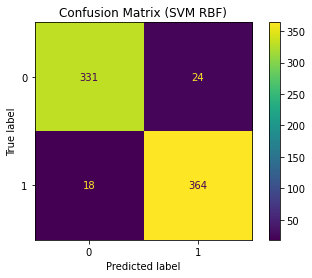

In [35]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix (SVM RBF)")
plt.show()

In [36]:
model = grid_lr.best_estimator_.named_steps['classifier']
coefs = model.coef_[0]

feature_names = X_train.columns

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
    "abs_coef": np.abs(coefs),
    "sign": np.where(coefs >= 0, "+", "−")
})

coef_df_sorted = coef_df.sort_values(by="abs_coef", ascending=False).reset_index(drop=True)

coef_df_sorted

,feature,coef,abs_coef,sign
0,MSTTR,-3.109115,3.109115,−
1,CCONJ,-1.876836,1.876836,−
2,VERB,1.127600,1.127600,+
3,PRON,0.861999,0.861999,+
4,function_words,-0.847933,0.847933,−
5,AUX,0.652903,0.652903,+
6,ADJ,0.647624,0.647624,+
7,DET,0.591006,0.591006,+
8,PROPN,0.510111,0.510111,+
9,NUM,0.491343,0.491343,+


In [37]:
result = permutation_importance(
    svc_pipeline_final, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc"
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": result.importances_mean
}).sort_values(by="importance", ascending=False)

importance_df

,feature,importance
3,MSTTR,0.128339
16,CCONJ,0.043373
7,PRON,0.016300
6,VERB,0.013839
5,function_words,0.008499
8,NUM,0.005616
12,PROPN,0.005609
1,avg_word_length,0.002244
0,word_count,0.002132
17,AUX,0.002085


In [38]:
pipeline_rf = Pipeline([
    ('classifier', RandomForestClassifier(
        random_state=RANDOM_STATE
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE) 

scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'precision': 'precision',
    'recall': 'recall'
}

rf_results = cross_validate(
    pipeline_rf,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

for metric in scoring.keys():
    mean_score = rf_results[f'test_{metric}'].mean()
    print(f"{metric}: {mean_score:.3f}")

accuracy: 0.926
f1: 0.928
roc_auc: 0.979
precision: 0.934
recall: 0.923


In [39]:
def objective(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical(
            'max_features',
            ['sqrt', 'log2']
        ),

        'class_weight': trial.suggest_categorical(
            'class_weight',
            [None, 'balanced']
        ),
        'random_state': RANDOM_STATE,
        'n_jobs': -1
    }

    model = RandomForestClassifier(**params)

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    )

    return scores.mean()

In [40]:
study = optuna.create_study(direction='maximize')

study.optimize(
    objective,
    n_trials=20
)

[I 2026-05-28 21:27:54,756] A new study created in memory with name: no-name-5ecf9c05-2c5d-41e3-9fff-5727ae9cd2b9
[I 2026-05-28 21:27:55,916] Trial 0 finished with value: 0.9683484574754573 and parameters: {'n_estimators': 120, 'max_depth': 4, 'min_samples_split': 17, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.9683484574754573.
[I 2026-05-28 21:27:57,718] Trial 1 finished with value: 0.9770611589382847 and parameters: {'n_estimators': 167, 'max_depth': 7, 'min_samples_split': 12, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 1 with value: 0.9770611589382847.
[I 2026-05-28 21:27:58,757] Trial 2 finished with value: 0.9610404896286532 and parameters: {'n_estimators': 159, 'max_depth': 3, 'min_samples_split': 13, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 1 with value: 0.9770611589382847.
[I 2026-05-28 21:28:00,034] Trial 3 finished with

In [41]:
print("Best params:")
print(study.best_params)

print("\nBest ROC-AUC:")
print(study.best_value)

Best params:
{'n_estimators': 200, 'max_depth': 12, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'log2', 'class_weight': 'balanced'}

Best ROC-AUC:
0.979244162686604


In [42]:
best_rf = RandomForestClassifier(
    **study.best_params,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

best_rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=12,
                       max_features='log2', min_samples_leaf=5,
                       n_estimators=200, n_jobs=-1, random_state=42)

In [43]:
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.9335142469470827
ROC-AUC: 0.9836368999336332


In [44]:
train_pred = best_rf.predict(X_train)
train_prob = best_rf.predict_proba(X_train)[:,1]

test_pred = best_rf.predict(X_test)
test_prob = best_rf.predict_proba(X_test)[:,1]

print("Train metrics")
print("Accuracy:",
      round(accuracy_score(y_train, train_pred), 3))

print("ROC-AUC:",
      round(roc_auc_score(y_train, train_prob), 3))

print()

print("Test metrics")
print("Accuracy:",
      round(accuracy_score(y_test, test_pred), 3))

print("ROC-AUC:",
      round(roc_auc_score(y_test, test_prob), 3))

Train metrics
Accuracy: 0.978
ROC-AUC: 0.998

Test metrics
Accuracy: 0.934
ROC-AUC: 0.984


In [45]:
rf_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 5, 10, 20],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2],
    'classifier__class_weight': [None, 'balanced']
}

In [46]:
grid_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=rf_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

print("Лучшие параметры:")
print(grid_rf.best_params_)

print("\nЛучший ROC-AUC:")
print(round(grid_rf.best_score_, 3))

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Лучшие параметры:
{'classifier__class_weight': 'balanced', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}

Лучший ROC-AUC:
0.98


In [47]:
rf_pipeline_final = grid_rf.best_estimator_

In [48]:
y_pred_rf = rf_pipeline_final.predict(X_test)

y_score_rf = rf_pipeline_final.predict_proba(X_test)[:,1]

print(f"Accuracy: {round(accuracy_score(y_test, y_pred_rf), 3)}")
print(f"F1: {round(f1_score(y_test, y_pred_rf), 3)}")
print(f"Precision: {round(precision_score(y_test, y_pred_rf), 3)}")
print(f"Recall: {round(recall_score(y_test, y_pred_rf), 3)}")
print(f"ROC-AUC: {round(roc_auc_score(y_test, y_score_rf), 3)}")

Accuracy: 0.943
F1: 0.945
Precision: 0.938
Recall: 0.953
ROC-AUC: 0.985


In [49]:
rf_model = rf_pipeline_final.named_steps['classifier']

importance_df_rf = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

importance_df_rf

,feature,importance
3,MSTTR,0.263552
16,CCONJ,0.165352
7,PRON,0.073710
4,yule,0.062061
17,AUX,0.053592
6,VERB,0.048736
2,avg_sentence_length,0.048600
0,word_count,0.036768
13,DET,0.031244
5,function_words,0.030868


In [50]:
rf_train_pred = grid_rf.best_estimator_.predict(X_train)
rf_test_pred = grid_rf.best_estimator_.predict(X_test)

print("Train accuracy:",
      accuracy_score(y_train, rf_train_pred))

print("Test accuracy:",
      accuracy_score(y_test, rf_test_pred))

Train accuracy: 0.9995477159656264
Test accuracy: 0.9430122116689281


In [51]:
lr_train_pred = lr_pipeline_final.predict(X_train)
lr_test_pred = lr_pipeline_final.predict(X_test)

print("LogReg")
print("Train Accuracy:",
      round(accuracy_score(y_train, lr_train_pred), 3))

print("Test Accuracy:",
      round(accuracy_score(y_test, lr_test_pred), 3))

print()


svm_linear_pipeline = pipeline_svm.fit(X_train, y_train)

svm_linear_train_pred = svm_linear_pipeline.predict(X_train)
svm_linear_test_pred = svm_linear_pipeline.predict(X_test)

print("SVM linear")
print("Train Accuracy:",
      round(accuracy_score(y_train, svm_linear_train_pred), 3))

print("Test Accuracy:",
      round(accuracy_score(y_test, svm_linear_test_pred), 3))

print()


svm_rbf_train_pred = svc_pipeline_final.predict(X_train)
svm_rbf_test_pred = svc_pipeline_final.predict(X_test)

print("SVM RBF")
print("Train Accuracy:",
      round(accuracy_score(y_train, svm_rbf_train_pred), 3))

print("Test Accuracy:",
      round(accuracy_score(y_test, svm_rbf_test_pred), 3))

print()


rf_train_pred = rf_pipeline_final.predict(X_train)
rf_test_pred = rf_pipeline_final.predict(X_test)

print("Random forest")
print("Train Accuracy:",
      round(accuracy_score(y_train, rf_train_pred), 3))

print("Test Accuracy:",
      round(accuracy_score(y_test, rf_test_pred), 3))

LogReg
Train Accuracy: 0.928
Test Accuracy: 0.944

SVM linear
Train Accuracy: 0.964
Test Accuracy: 0.944

SVM RBF
Train Accuracy: 0.957
Test Accuracy: 0.943

Random forest
Train Accuracy: 1.0
Test Accuracy: 0.943


In [52]:
pipeline_svm_shap = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', SVC(
        kernel='rbf',
        C=10,
        gamma=0.01,
        class_weight='balanced',
        probability=True,
        random_state=RANDOM_STATE
    ))
])

In [53]:
pipeline_svm_shap.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 SVC(C=10, class_weight='balanced', gamma=0.01,
                     probability=True, random_state=42))])

In [54]:
def model_predict(data):
    return pipeline_svm_shap.predict_proba(data)

In [55]:
X_sample = X_train.sample(100, random_state=42)
X_test_sample = X_test.sample(50, random_state=42)

In [56]:
explainer = shap.KernelExplainer(
    model_predict,
    X_sample
)

In [57]:
shap_values = explainer.shap_values(X_test_sample)

  0%|          | 0/50 [00:00<?, ?it/s]

In [58]:
shap_values_class1 = shap_values[:, :, 1]

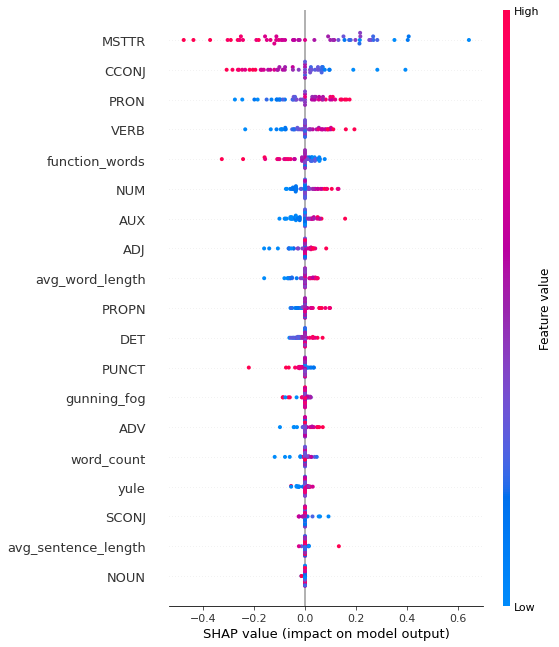

In [59]:
shap.summary_plot(
    shap_values_class1,
    X_test_sample
)

In [61]:
lr_pipeline_final = grid_lr.best_estimator_

In [62]:
explainer_lr = shap.Explainer(
    lr_pipeline_final.predict,
    X_train
)

In [63]:
shap_values_lr = explainer_lr(X_test)

PermutationExplainer explainer: 738it [00:36, 16.85it/s]                                                               


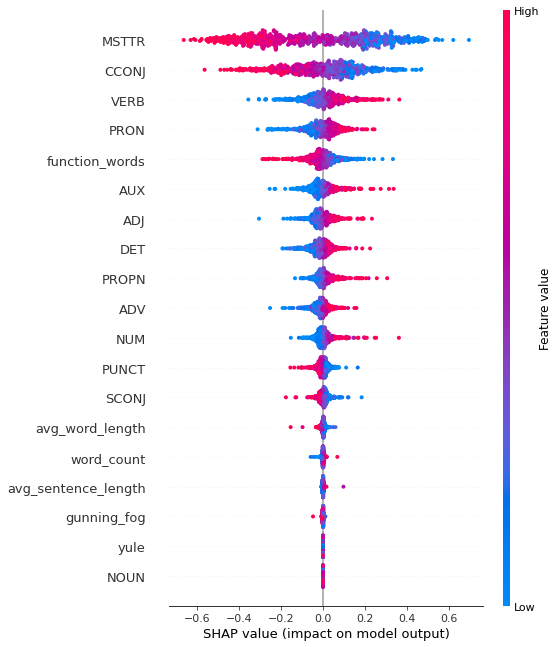

In [64]:
shap.summary_plot(
    shap_values_lr.values,
    X_test
)

In [65]:
base_value = shap_values_lr.base_values.mean()

In [67]:
pipeline_rf = Pipeline([
    ('classifier', RandomForestClassifier(
        class_weight='balanced',
        max_depth=None,
        min_samples_leaf=1,
        min_samples_split=5,
        n_estimators=200,
        random_state=42
    ))
])

In [68]:
pipeline_rf.fit(X_train, y_train)

explainer_rf = shap.TreeExplainer(
    pipeline_rf.named_steps['classifier']
)

shap_values_rf = explainer_rf.shap_values(X_test)

shap_values_class1 = shap_values_rf[:, :, 1]

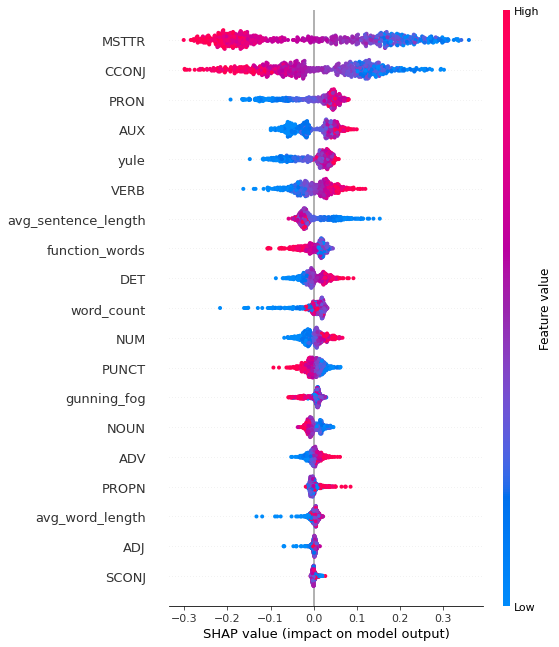

In [69]:
shap.summary_plot(
    shap_values_class1,
    X_test
)

In [70]:
explainer_lr = shap.Explainer(
    lambda x: lr_pipeline_final.predict_proba(x)[:, 1],
    X_train
)

In [71]:
shap_values_lr = explainer_lr(X_test)

PermutationExplainer explainer: 738it [00:30, 16.53it/s]                                                               


In [78]:
best_lr = grid_lr.best_estimator_

df['human_probability'] = best_lr.predict_proba(X)[:,1]

most_ai = df.sort_values(by='human_probability', ascending=False)

most_ai[['word_count', 'human_probability']].head(10)

,word_count,human_probability
1520,396,1.000000
2317,452,0.999999
1487,376,0.999999
2594,381,0.999999
3120,396,0.999999
3116,393,0.999999
3420,400,0.999998
2353,400,0.999998
3285,401,0.999998
2636,386,0.999997


In [79]:
best_lr = grid_lr.best_estimator_

df['ai_probability'] = best_lr.predict_proba(X)[:,0]

most_ai = df.sort_values(by='ai_probability', ascending=False)

most_ai[['word_count', 'ai_probability']].head(10)

,word_count,ai_probability
1529,405,0.999991
1849,376,0.999965
1265,408,0.999962
2573,375,0.999962
1099,367,0.999961
1693,351,0.999960
3623,321,0.999947
2312,416,0.999945
2112,353,0.999945
2042,449,0.999940


In [81]:
df['human_probability_svm'] = svc_pipeline_final_proba.predict_proba(X)[:,1]
most_ai_svm = df.sort_values(
    by='human_probability_svm',
    ascending=False
)

most_ai_svm[['word_count', 'human_probability_svm']].head(10)

,word_count,human_probability_svm
2335,400,1.0
2155,441,1.0
2594,381,1.0
2604,382,1.0
1043,392,1.0
1170,386,1.0
1664,347,1.0
2325,445,1.0
1748,411,1.0
1881,424,1.0


In [82]:
df['ai_probability_svm'] = svc_pipeline_final_proba.predict_proba(X)[:,0]
most_ai_svm = df.sort_values(
    by='ai_probability_svm',
    ascending=False
)

most_ai_svm[['word_count', 'ai_probability_svm']].head(10)

,word_count,ai_probability_svm
422,377,0.999996
2819,489,0.999994
2573,375,0.999988
416,464,0.999987
2667,377,0.999984
2180,402,0.999976
1964,464,0.999975
206,459,0.999975
3303,289,0.999974
2112,353,0.999973


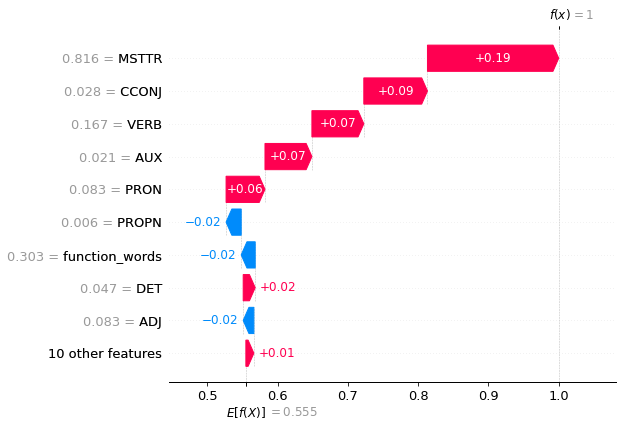

In [83]:
sample_idx = 1520
shap_values_one = explainer_lr(X.iloc[[sample_idx]])
shap.plots.waterfall(shap_values_one[0])

In [84]:
indices = [1520]
X_selected = X.loc[indices]
shap_values = explainer.shap_values(X_selected)
shap_values_class1 = shap_values[:, :, 1]

  0%|          | 0/1 [00:00<?, ?it/s]

In [86]:
i = 0

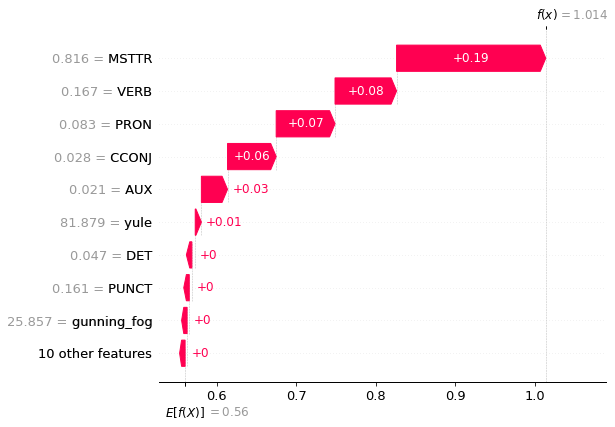

In [87]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_class1[i],
        base_values=base_value,
        data=X_selected.iloc[i],
        feature_names=X_selected.columns.tolist()
    )
)

In [88]:
indices = [1520, 1529, 2335, 422]

X_selected = X.loc[indices]

shap_values = explainer_rf.shap_values(X_selected)

shap_values_class1 = shap_values[:, :, 1]

base_value = explainer_rf.expected_value[1]


Индекс текста: 1520
Настоящий класс: 1


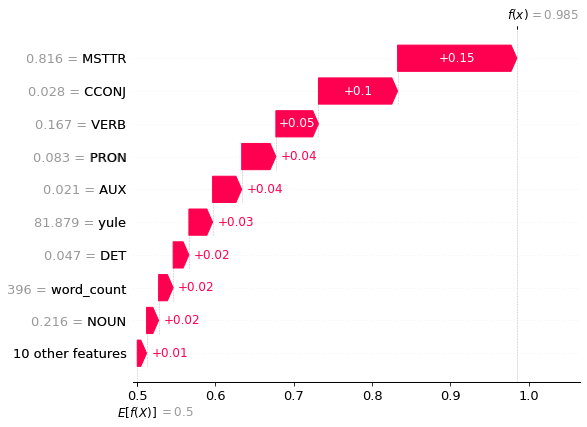


Индекс текста: 1529
Настоящий класс: 0


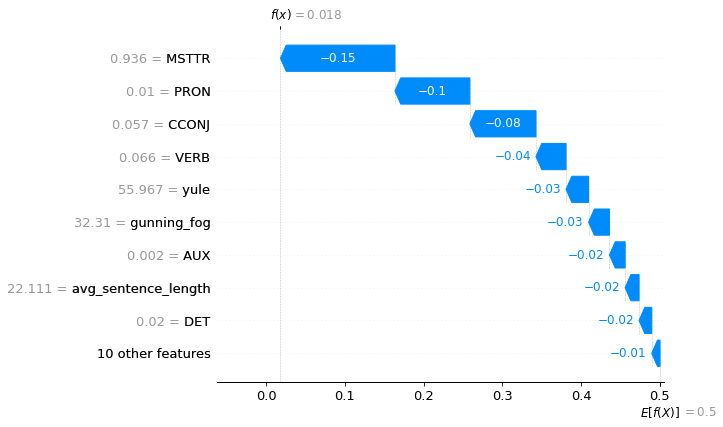


Индекс текста: 2335
Настоящий класс: 1


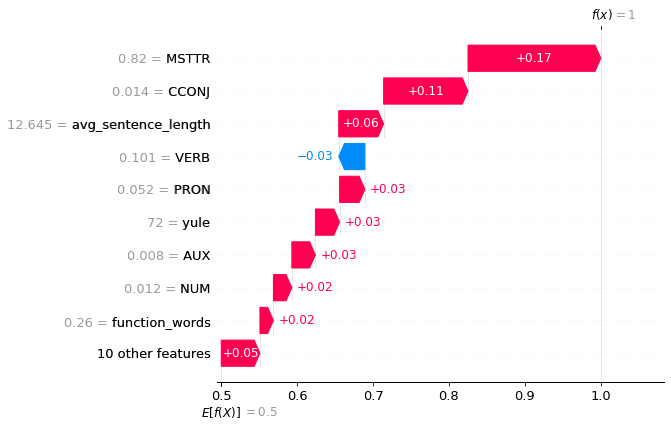


Индекс текста: 422
Настоящий класс: 0


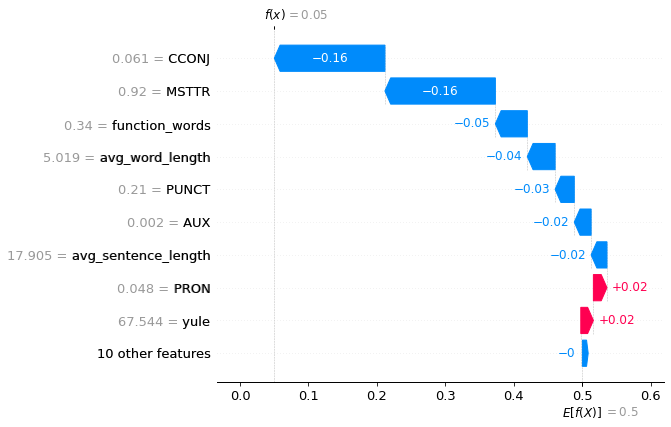

In [89]:
for i in range(len(indices)):
    
    print(f"\nИндекс текста: {indices[i]}")
    print(f"Настоящий класс: {df.loc[indices[i], 'ai_human']}")
    
    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values_class1[i],
            base_values=base_value,
            data=X_selected.iloc[i],
            feature_names=X_selected.columns.tolist()
        )
    )

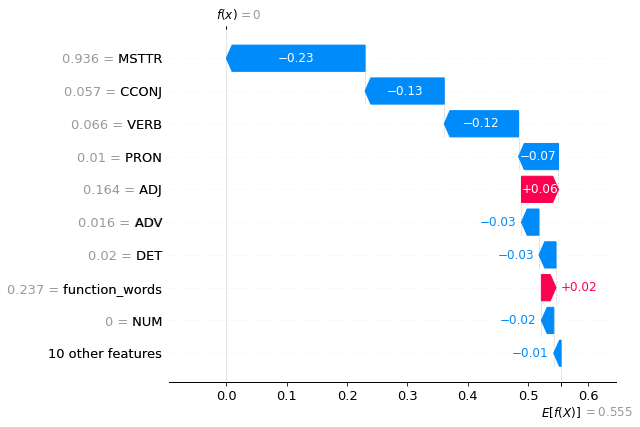

In [90]:
sample_idx = 1529
shap_values_one = explainer_lr(X.iloc[[sample_idx]])
shap.plots.waterfall(shap_values_one[0])

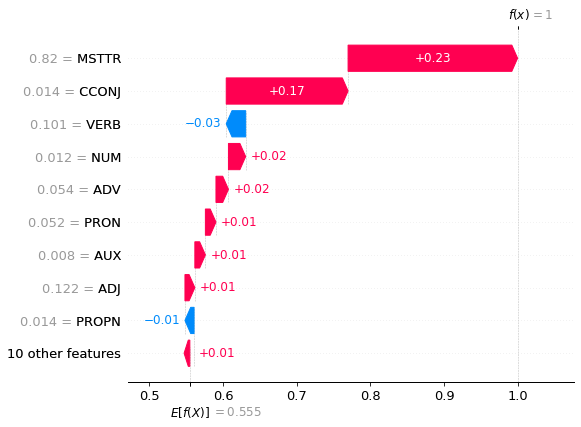

In [92]:
sample_idx = 2335
shap_values_one = explainer_lr(X.iloc[[sample_idx]])
shap.plots.waterfall(shap_values_one[0])